# Distribution Analysis

Fitting and goodness-of-fit pipeline for the two candidate return distributions used in this
project. **Part 1** fits the **Johnson SU** distribution; **Part 2** repeats the identical workflow
for the **Azzalini & Capitanio (2003) Skewed-t**. Both families are implemented in the single
`auxi.distribution_analysis` module. Downstream risk metrics (entropy, skewness) live in
`risk_metrics.ipynb` / `auxi.vulnerability_metrics`.

## Importing

In [8]:
import pandas as pd
import numpy as np
import os

from datetime import datetime, timedelta

os.chdir("C:/Users/Alejandro/Documents/MQuEA/TFM/main_code")

import auxi.distribution_analysis as da
from auxi.data import import_data
from auxi.qreg import insample_direct_forecasting
from pathlib import Path
import auxi.diagnostics as diags

In [9]:
data = import_data(freq="Daily")

c:\Users\Alejandro\Documents\MQuEA\TFM\main_code\auxi\data.py:353: DtypeWarning: Columns (40,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  panel = pd.read_csv(csv_path, index_col=0, parse_dates=True)


# Part 1 — Johnson SU Distribution Fitting to Data

### Fitting to the empirical returns

JOHNSON SU — FITTED PARAMETERS
  gamma  (skewness)      : +0.014494
  delta  (shape)         : 1.196563
  loc    (location)      : +0.079836
  scale  (scale)         : 1.922766
--------------------------------------------------
  Implied mean           : +0.046810
  Implied std dev        : 2.371778
  Skew direction         : left (negative)  (gamma=+0.0145)
  Tail thickness         : moderate/light  (delta=1.1966)


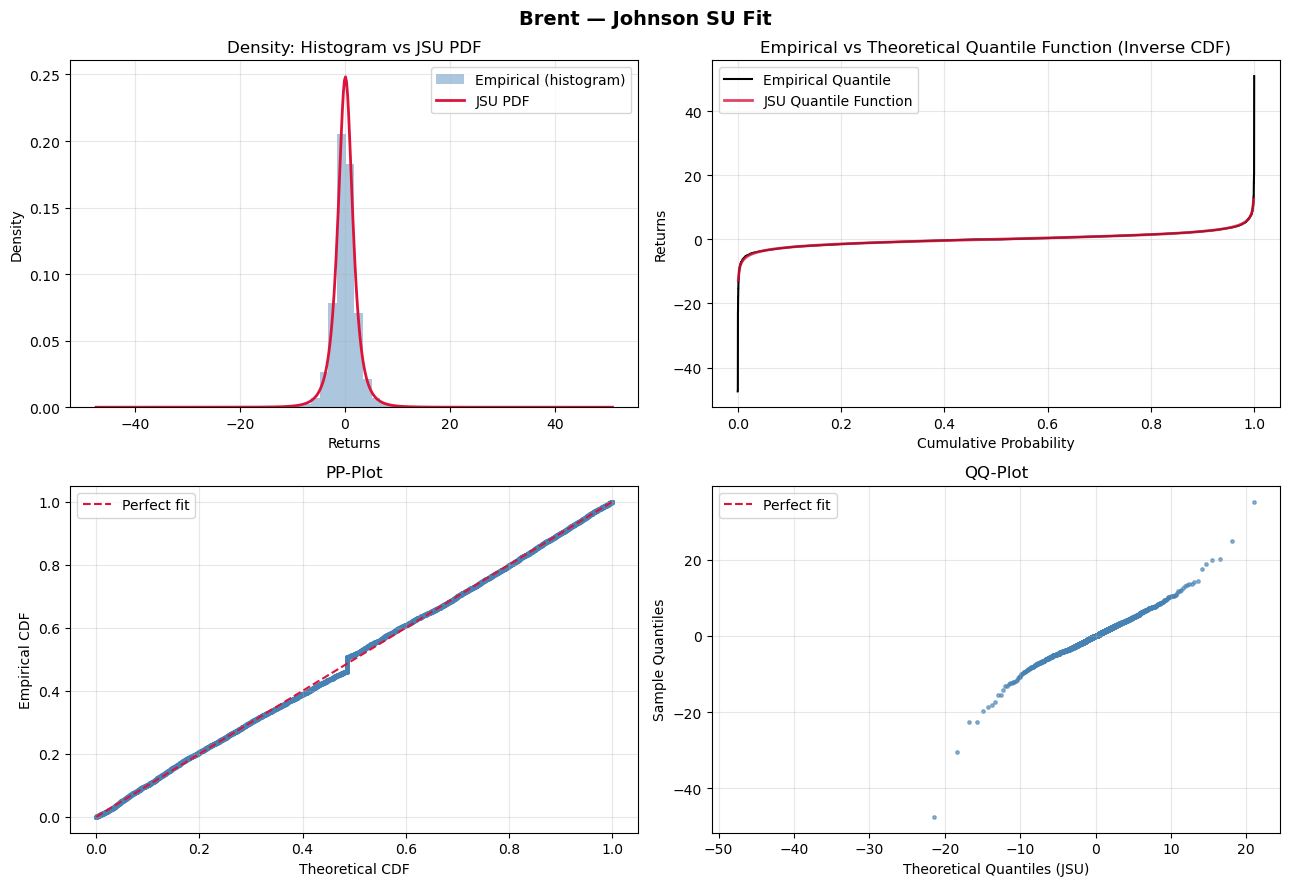


KOLMOGOROV-SMIRNOV TEST  (Monte Carlo corrected)
  KS Statistic  D_real    : 0.025057
  Replications  M         : 100
  Significance  α         : 0.10
  Monte Carlo p-value     : 0.0000
--------------------------------------------------
  CONCLUSION: REJECT H₀ — JSU does NOT fit the data.


In [10]:
returns = np.asarray(data["Brent_Return"].dropna())
params, ks = diags.fit_and_diagnose_jsu(returns, ticker="Brent", M=100,
                                     alpha=0.10, random_state=1403)

### Fitting to the in-sample direct forecasted quantiles

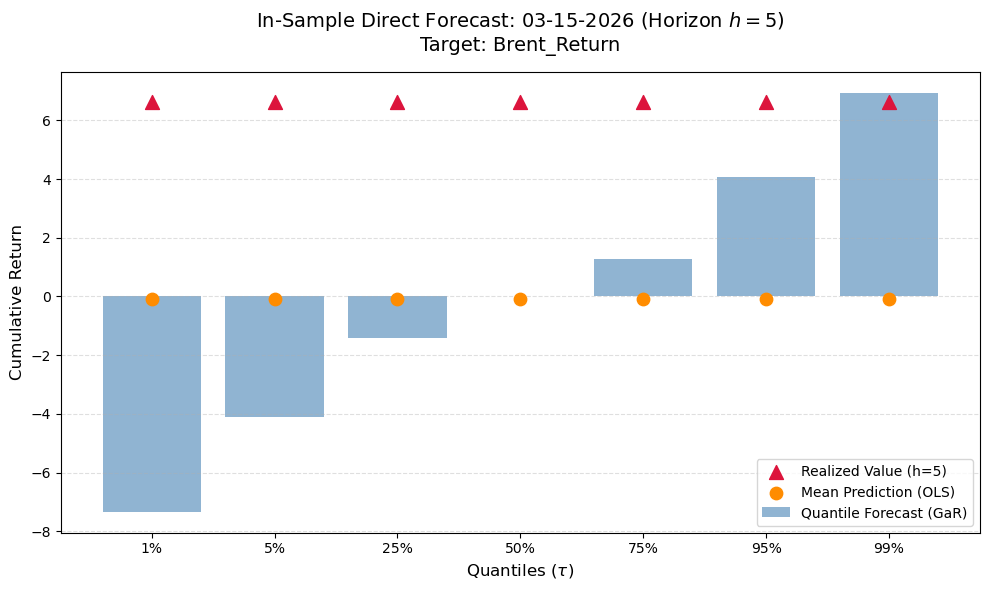

In [11]:
controls = ["usd_index_ld", "Realized_Volatility", "badi_ld"]

horizon = 5
date    = "03-15-2026"

fc = insample_direct_forecasting(
    df             = data,
    x              = "GPRD",
    y              = "Brent_Return",
    quantiles      = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99],
    train_end_date = date,
    h              = horizon
)

d     = datetime.strptime(date, "%m-%d-%Y")
target_date = d + timedelta(days=horizon)

forecast        = fc["Forecast"].tolist()
quantiles       = fc["Quantile"].tolist()
observed_values = fc["Realized"].tolist()

realized = data["Brent_Return"].loc[:date].dropna().values

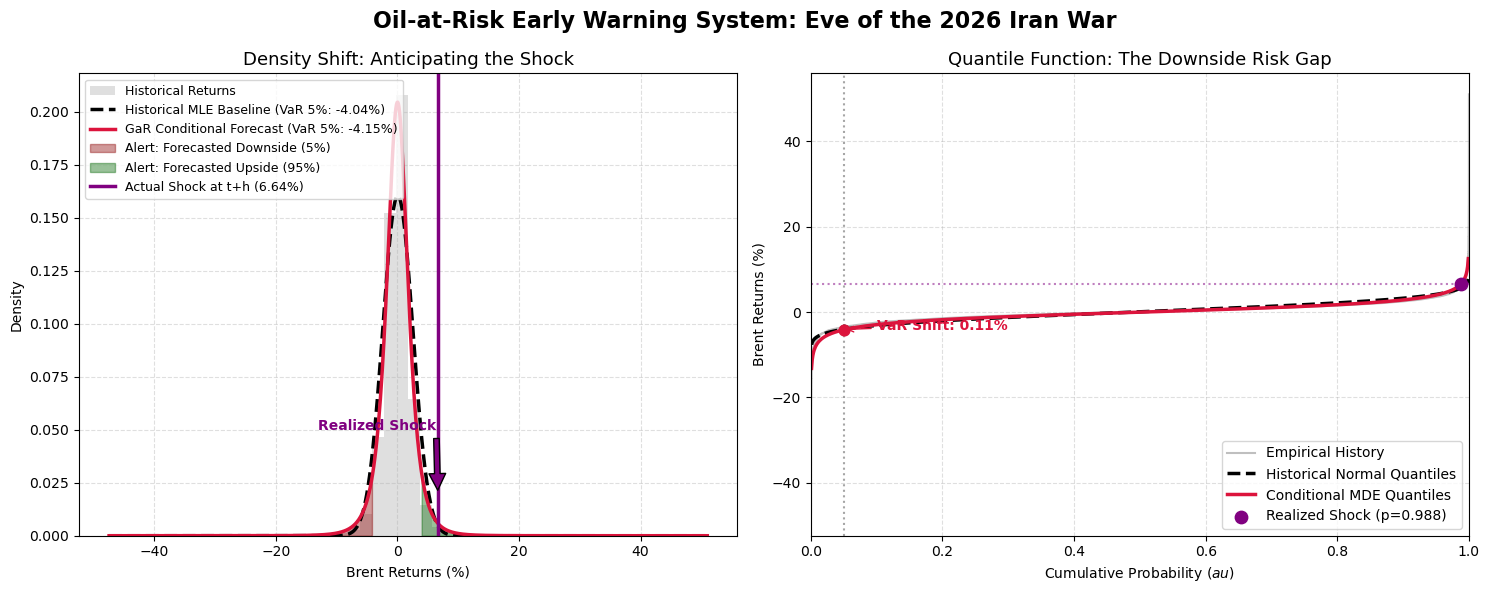

In [12]:
cond_params = da.mde_jsu_weighted(fcq=forecast, tau_levels=quantiles)

da.compare_distributions_jsu(
    returns         = realized,
    cond_params     = cond_params,
    date_str        = "Eve of the 2026 Iran War",
    hist_mean       = np.average(realized),
    hist_std        = np.std(realized),
    realized_return = observed_values[0]
)

In [13]:
import json as _json, datetime

# ── OOS Evaluation Settings ─────────────────────────────────────────────
# Applies to both Part 1 (JSU) and Part 2 (Skewed-t).
# Change any parameter here — OOS_DIR is derived automatically.
horizon      = 5
training_end = "12-30-2024"
tau_levels   = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
x_var        = "GPRD_MA7"
y_var        = "Brent_Return"
control_vars = [
    "usd_index_ld",
    "Realized_Volatility",
    "badi_ld"
]

# ── Derive results folder from settings ──────────────────────────────
_x_slug = x_var.lower()
OOS_DIR = Path(f"../results/oos/h{horizon}_{_x_slug}")
OOS_DIR.mkdir(parents=True, exist_ok=True)

_cfg_file = OOS_DIR / "config.json"
if not _cfg_file.exists():
    _cfg = {
        "description": f"OoS — h={horizon}, {x_var} specification",
        "horizon": horizon, "x_var": x_var, "y_var": y_var,
        "controls": control_vars, "quantiles": tau_levels,
        "training_end_jsu": training_end,
        "training_end_skewt": training_end,
        "sample_start": "1990-01-01",
        "created": datetime.date.today().strftime("%Y-%m-%d"),
    }
    with open(_cfg_file, "w") as _f:
        _json.dump(_cfg, _f, indent=2)
    print(f"New config created → {OOS_DIR.name}/")
else:
    with open(_cfg_file) as _f:
        _cfg = _json.load(_f)
    print(f"Existing config loaded → {OOS_DIR.name}/")

print(f"  h={horizon}, training_end={training_end}, x={x_var}")

Existing config loaded → h5_gprd_ma7/
  h=5, training_end=12-30-2024, x=GPRD_MA7


In [14]:
# ── OOS JSU: load or compute ────────────────────────────────────────────
_p = OOS_DIR / "jsu_params.parquet"
if _p.exists():
    _df            = pd.read_parquet(_p)
    realized_oos   = _df["realized"].values
    parameters_oos = _df[["a", "b", "loc", "scale"]].values
else:
    realized_oos, parameters_oos = da.generate_oos_parameters(
        df             = data,
        x              = x_var,
        y              = y_var,
        controls       = control_vars,
        quantiles      = tau_levels,
        h              = horizon,
        train_end_date = training_end
    )
    _df = pd.DataFrame(parameters_oos, columns=["a", "b", "loc", "scale"])
    _df.insert(0, "realized", realized_oos)
    _df.to_parquet(_p)

print(f"JSU OOS params loaded: {len(realized_oos)} observations")

JSU OOS params loaded: 344 observations


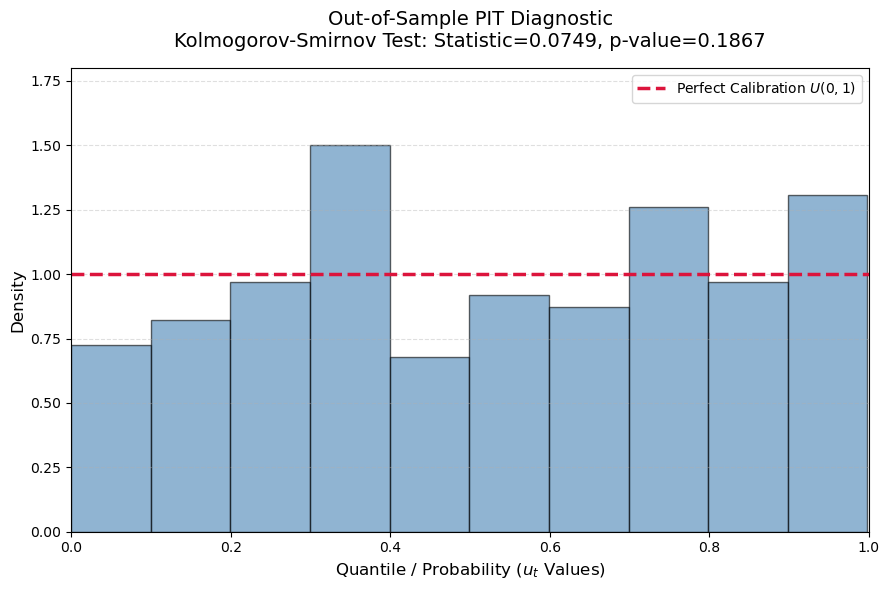

In [15]:
# ── PIT uniformity test — JSU ────────────────────────────────────────────
u_t, ks_stat, ks_pval = diags.evaluate_oos_pit(
    realized_returns  = realized_oos,
    forecasted_params = parameters_oos,
    bins              = 10
)

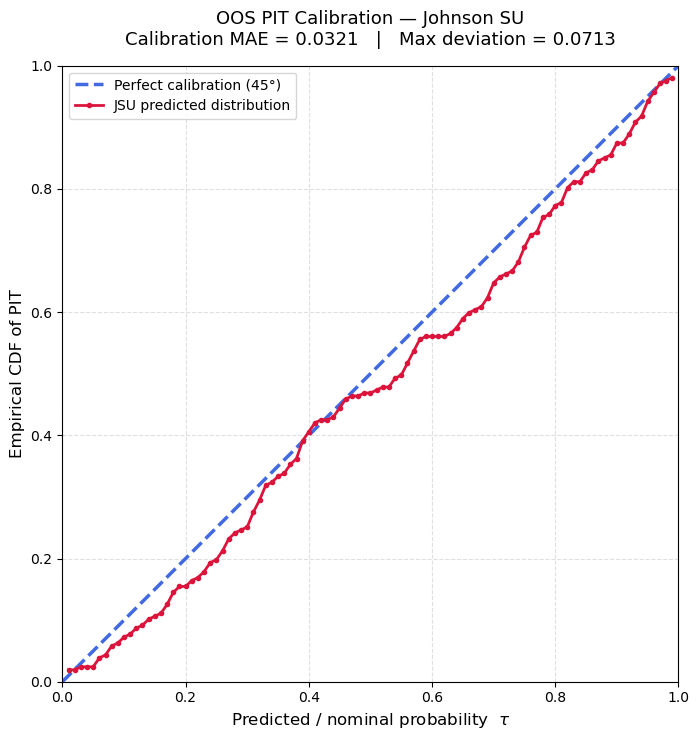

(array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
        0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
        0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
        0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
        0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
        0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
        0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
        0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
        0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]),
 array([0.01932367, 0.01932367, 0.02415459, 0.02415459, 0.02415459,
        0.03864734, 0.04347826, 0.05797101, 0.06280193, 0.07246377,
        0.07729469, 0.08695652, 0.09178744, 0.10144928, 0.10628019,
        0.11111111, 0.12560386, 0.14492754, 0.15458937, 0.15458937,
        0.16425121, 0.16908213, 0.17874396, 0.19323671, 0.19

In [16]:
# ── PIT calibration curve (PP-plot) — JSU ────────────────────────────────
diags.plot_oos_pit_calibration(u_t, title="OOS PIT Calibration — Johnson SU",
                               curve_label="JSU predicted distribution")

# Part 2 — Skewed-t Distribution Fitting to Data

### Fitting to the empirical returns

### Fitting to the in-sample direct forecasted quantiles

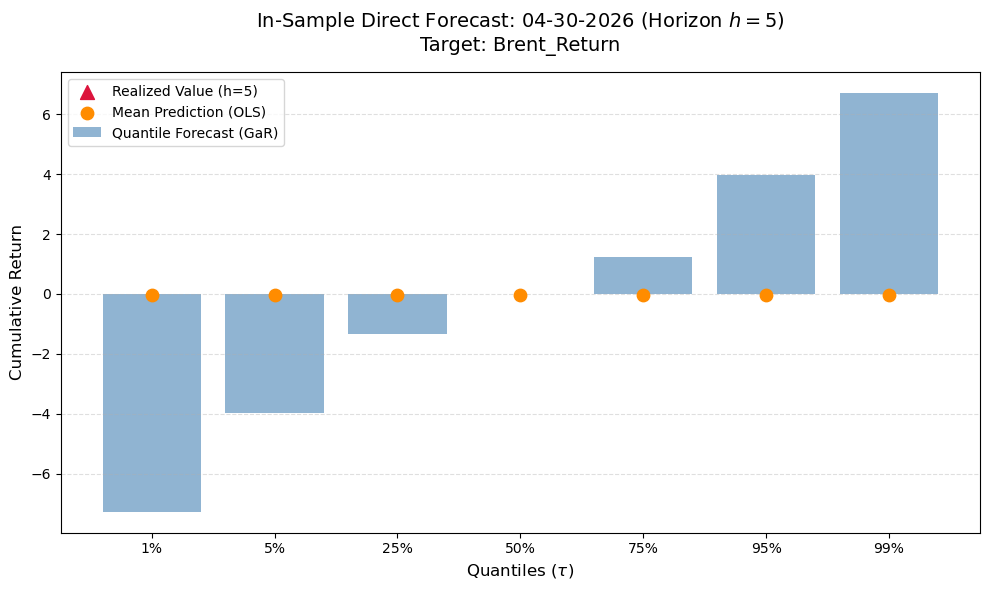

In [17]:
# In-sample Skewed-t fit on the latest available date
date = data.index[-1].strftime("%m-%d-%Y")

fc_insample = insample_direct_forecasting(
    df             = data,
    x              = "GPRD",
    y              = y_var,
    quantiles      = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99],
    train_end_date = date,
    h              = horizon
)

target_date     = data.index[-1] + pd.Timedelta(days=horizon)
forecast        = fc_insample["Forecast"].tolist()
quantiles       = fc_insample["Quantile"].tolist()
observed_values = fc_insample["Realized"].tolist()
realized        = data[y_var].dropna().values

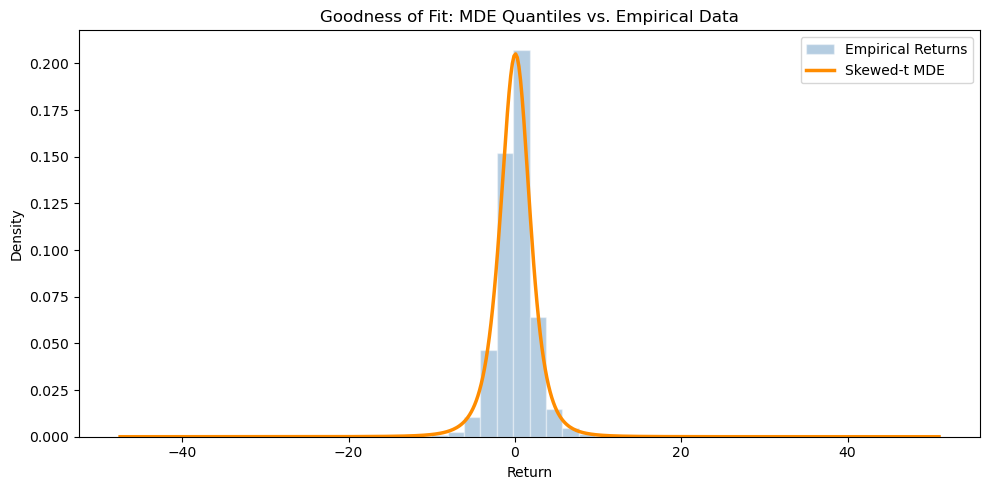

In [18]:
cond_params   = da.mde_distfit_skewt(fcq=forecast, tau_levels=quantiles)
uncond_params = da.fit_skewt(realized)

da.plot_mde_skewt_fit(
    returns    = realized,
    mde_params = cond_params,
    title      = "Goodness of Fit: MDE Quantiles vs. Empirical Data"
)

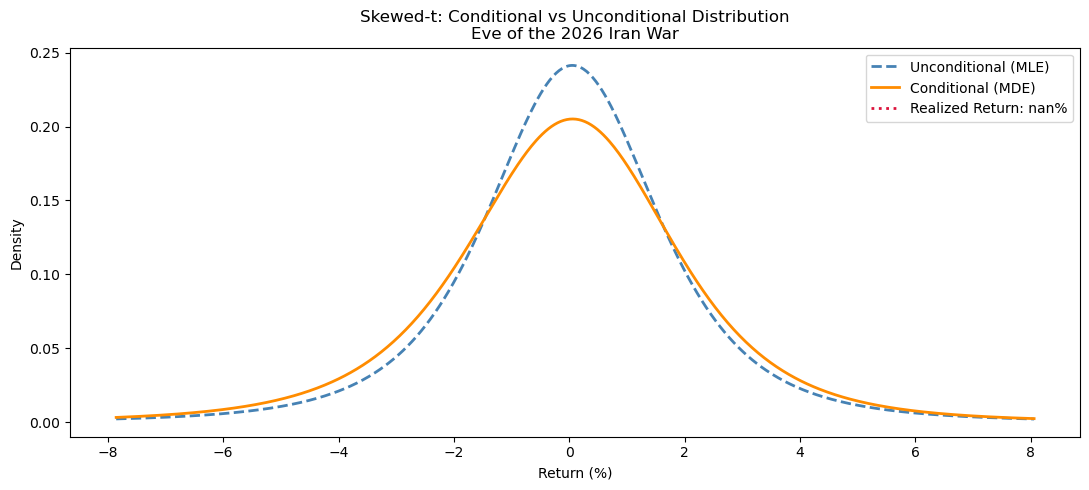

  5th pct — Conditional: -4.030%  |  Unconditional: -3.437%
  P(R ≤ realized) — Conditional: nan  |  Unconditional: nan


In [19]:
da.compare_distributions_skewt(
    returns         = realized,
    uncond_params   = uncond_params,
    cond_params     = cond_params,
    date_str        = "Eve of the 2026 Iran War",
    realized_return = observed_values[0]
)

In [ ]:
# ── OOS Skewed-t: load or compute ───────────────────────────────────────
_p = OOS_DIR / "skewt_params.parquet"
if _p.exists():
    _df            = pd.read_parquet(_p)
    realized_oos   = _df["realized"].tolist()
    parameters_oos = list(_df[["df_param", "a", "loc", "scale"]].itertuples(index=False, name=None))
else:
    realized_oos, parameters_oos = da.generate_oos_parameters_skewt(
        df             = data,
        x              = x_var,
        y              = y_var,
        controls       = control_vars,
        quantiles      = tau_levels,
        h              = horizon,
        train_end_date = training_end
    )
    _df = pd.DataFrame(parameters_oos, columns=["df_param", "a", "loc", "scale"])
    _df.insert(0, "realized", realized_oos)
    _df.to_parquet(_p)

print(f"Skewed-t OOS params loaded: {len(realized_oos)} observations")

OOS Skewed-t MDE (h=5):   1%|          | 4/344 [11:05<13:02:21, 138.06s/it]

OOS Skewed-t MDE (h=5):   1%|▏         | 5/344 [11:11<8:32:42, 90.74s/it]  

OOS Skewed-t MDE (h=5):   3%|▎         | 9/344 [24:42<13:57:18, 149.97s/it]

OOS Skewed-t MDE (h=5):   3%|▎         | 10/344 [24:50<9:50:32, 106.08s/it]

OOS Skewed-t MDE (h=5):   4%|▍         | 14/344 [37:19<12:57:59, 141.45s/it]

...

OOS Skewed-t MDE (h=5):   7%|▋         | 24/344 [1:01:52<9:58:52, 112.29s/it] 

OOS Skewed-t MDE (h=5):   7%|▋         | 25/344 [1:01:57<7:06:59, 80.31s/it] 

OOS Skewed-t MDE (h=5):   8%|▊         | 29/344 [1:12:12<10:13:13, 116.81s/it]

OOS Skewed-t MDE (h=5):   9%|▊         | 30/344 [1:12:20<7:19:28, 83.98s/it]  

OOS Skewed-t MDE (h=5):   9%|▉         | 32/344 [1:18:35<11:48:00, 136.16s/it]

In [ ]:
# ── PIT uniformity test — Skewed-t ──────────────────────────────────────
u_t, ks_stat, ks_pval = diags.evaluate_oos_pit_skewt(
    realized_returns  = realized_oos,
    forecasted_params = parameters_oos,
    bins              = 10
)

In [ ]:
# ── PIT calibration curve (PP-plot) — Skewed-t ──────────────────────────
diags.plot_oos_pit_calibration(u_t, title="OOS PIT Calibration — Azzalini Skewed-t",
                               curve_label="Skewed-t predicted distribution")